# PCA vs Raw Features – Breast Cancer Dataset

github - https://github.com/shashi7310/machine-learning-/tree/main

#### Import necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
sns.set_palette("colorblind")

plt.rcParams["figure.figsize"] = (10,6)

#### Load dataset

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)

df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#### Dataset Overview

In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


#### Target distribution

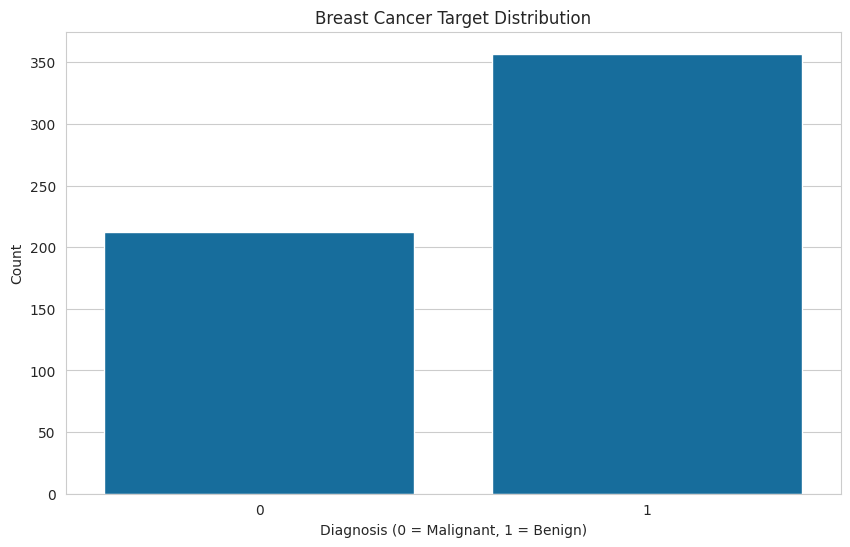

In [ ]:
sns.countplot(x="target", data=df)

plt.title("Breast Cancer Target Distribution")

plt.xlabel("Diagnosis (0 = Malignant, 1 = Benign)")

plt.ylabel("Count")

plt.savefig(
    "figure1_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Train - Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Standardize Features

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#### Logistic Regression

In [ ]:
model_raw = LogisticRegression(max_iter=5000)

model_raw.fit(X_train_scaled, y_train)

pred_raw = model_raw.predict(X_test_scaled)

accuracy_raw = accuracy_score(y_test, pred_raw)

print("Accuracy with Raw Features:", accuracy_raw)

Accuracy with Raw Features: 0.9736842105263158


#### Applying PCA

In [ ]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

Cumulative Explained Variance

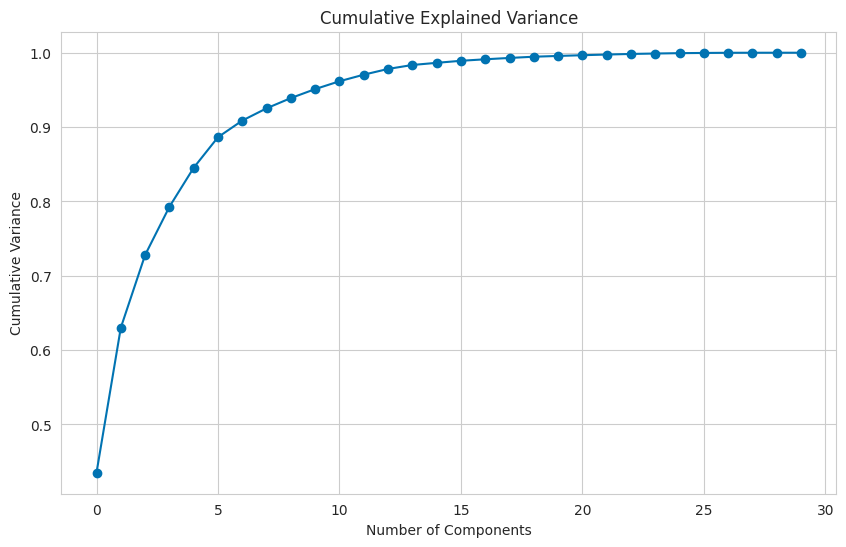

In [ ]:
explained_variance = pca.explained_variance_ratio_

plt.plot(
    np.cumsum(explained_variance),
    marker="o"
)

plt.title("Cumulative Explained Variance")

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Variance")

plt.grid(True)

plt.savefig(
    "figure2_cumulative_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### PCA Scatter Plot

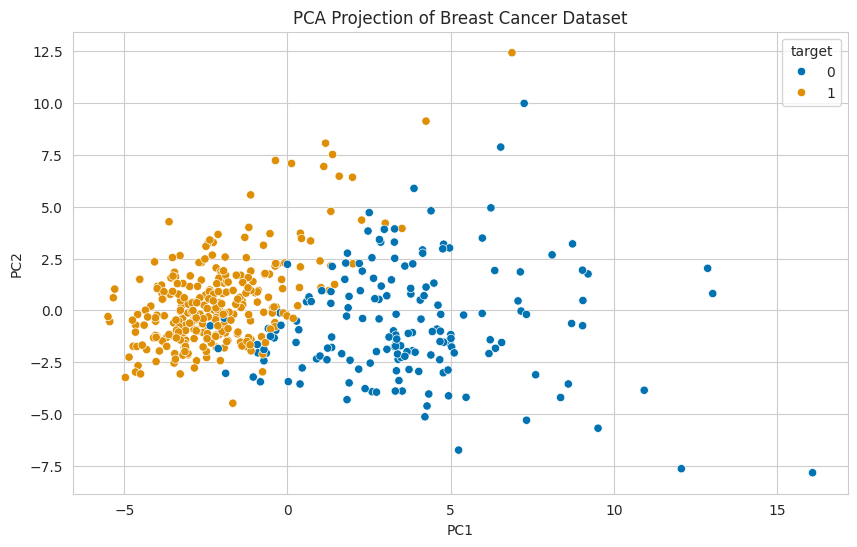

In [ ]:
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_pca_2d,
    columns=["PC1","PC2"]
)

pca_df["target"] = y_train

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="target",
    palette="colorblind"
)

plt.title("PCA Projection of Breast Cancer Dataset")

plt.savefig(
    "figure3_pca_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Bar Plot

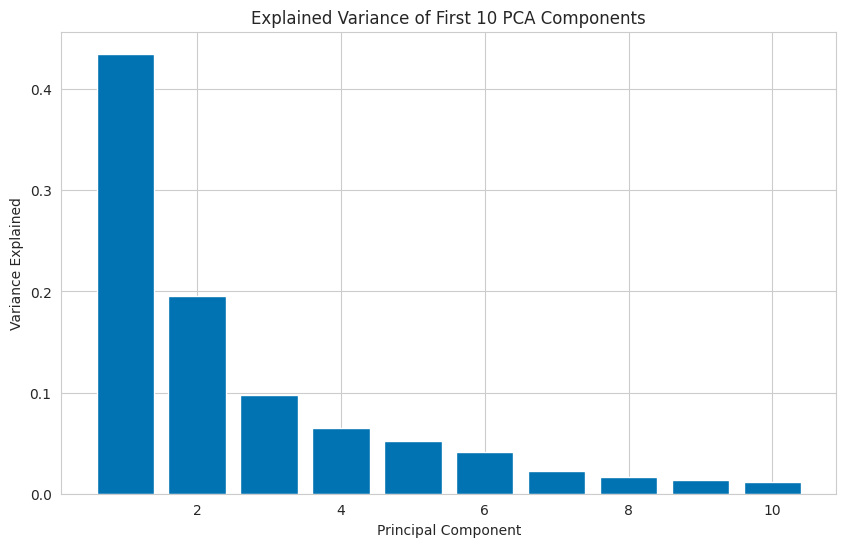

In [ ]:
plt.bar(
    range(1,11),
    explained_variance[:10]
)

plt.title("Explained Variance of First 10 PCA Components")

plt.xlabel("Principal Component")

plt.ylabel("Variance Explained")

plt.savefig(
    "figure4_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### PCA Reduced Components(95%) Variance

In [ ]:
pca_reduced = PCA(n_components=0.95)

X_train_pca_reduced = pca_reduced.fit_transform(X_train_scaled)

X_test_pca_reduced = pca_reduced.transform(X_test_scaled)

print("Original features:", X_train.shape[1])

print("Reduced features:", X_train_pca_reduced.shape[1])

Original features: 30
Reduced features: 10


#### Logistic Regression(PCA Features)

In [ ]:
model_pca = LogisticRegression(max_iter=5000)

model_pca.fit(X_train_pca_reduced, y_train)

pred_pca = model_pca.predict(X_test_pca_reduced)

accuracy_pca = accuracy_score(y_test, pred_pca)

print("Accuracy with PCA:", accuracy_pca)

Accuracy with PCA: 0.9824561403508771


#### Accuracy Comparision Plot

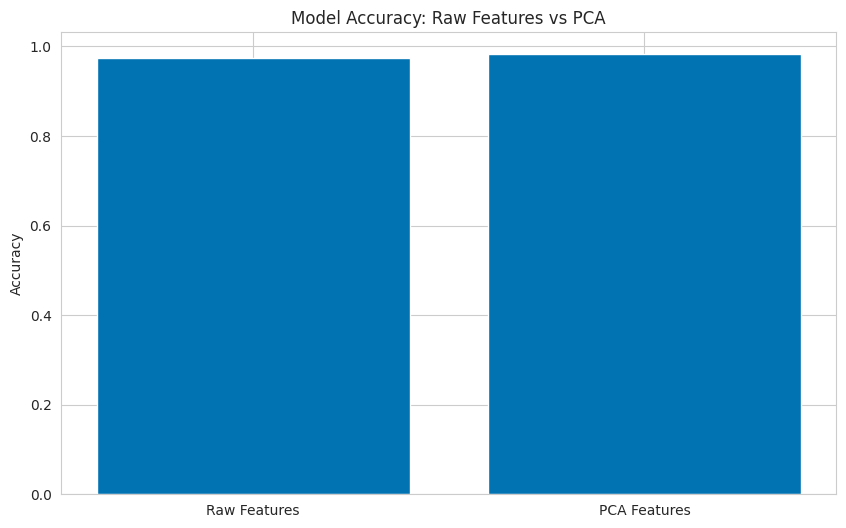

In [ ]:
methods = ["Raw Features", "PCA Features"]

scores = [accuracy_raw, accuracy_pca]

plt.bar(methods, scores)

plt.title("Model Accuracy: Raw Features vs PCA")

plt.ylabel("Accuracy")

plt.savefig(
    "figure5_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Heatmap

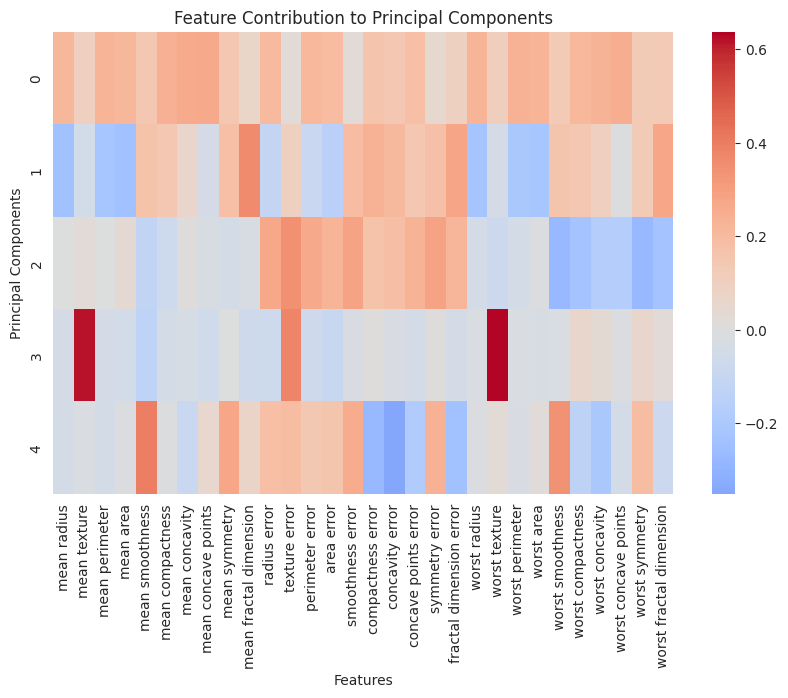

In [ ]:
loadings = pd.DataFrame(
    pca.components_[:5],
    columns=feature_names
)

sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Contribution to Principal Components")

plt.xlabel("Features")

plt.ylabel("Principal Components")

plt.savefig(
    "figure6_pca_feature_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(classification_report(
    y_test,
    pred_pca,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### Confusion Matrix

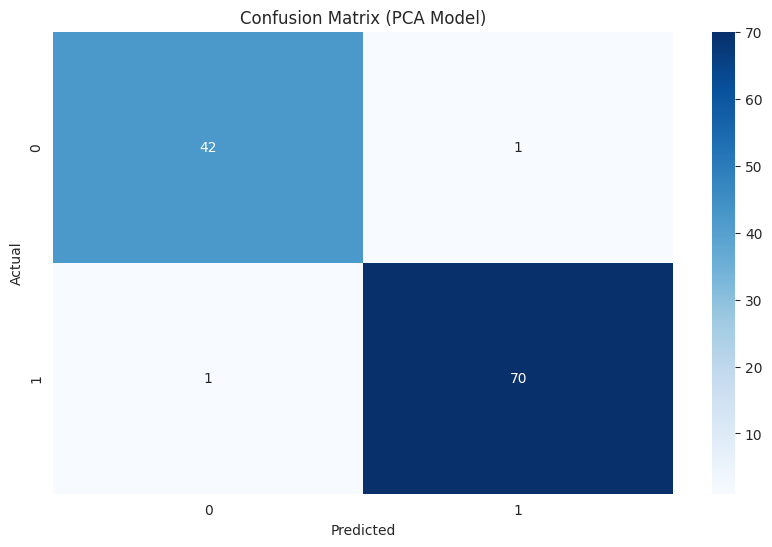

In [ ]:
cm = confusion_matrix(y_test, pred_pca)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix (PCA Model)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "figure7_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()